In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = "/content/drive/MyDrive/Chest_XRay2017.zip"

In [ ]:
import zipfile
import os
zip_path = "/content/Chest_XRay2017.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# Numerical & Data Handling
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    f1_score
)
# Image Processing
import cv2

In [ ]:
# Enable GPU check
print("GPU:", tf.config.list_physical_devices('GPU'))

# Speed optimization
tf.keras.mixed_precision.set_global_policy('mixed_float16')

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
DATA_DIR = "/content/chest_xray"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR + "/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [ ]:
# Optimizing pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
images = []
labels = []

for x, y in train_ds.take(10):
    images.extend(x.numpy())
    labels.extend(y.numpy())

images = np.array(images)
labels = np.array(labels)

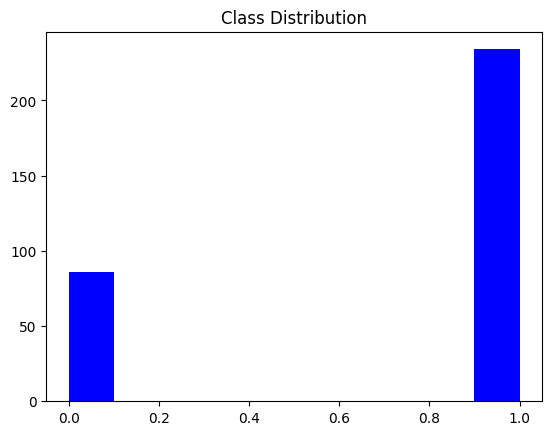

In [ ]:
#Class Distribution
plt.figure()
plt.hist(labels, color='blue')
plt.title("Class Distribution")
plt.show()

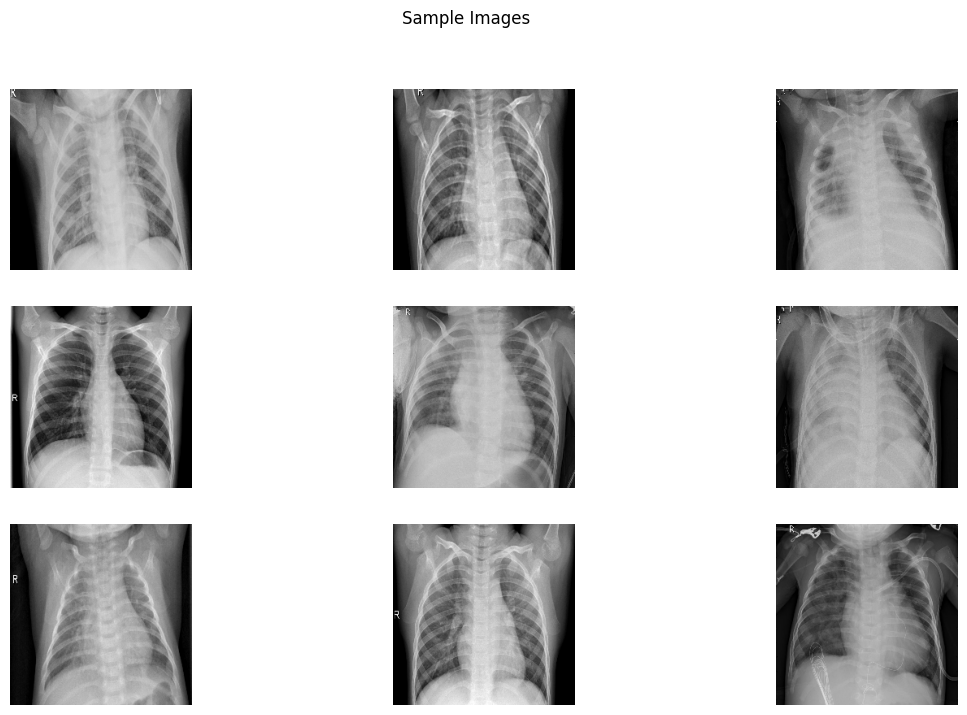

In [ ]:
#Sample Images
plt.figure(figsize=(14,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].astype("uint8"))
    plt.axis("off")
plt.suptitle("Sample Images")
plt.show()

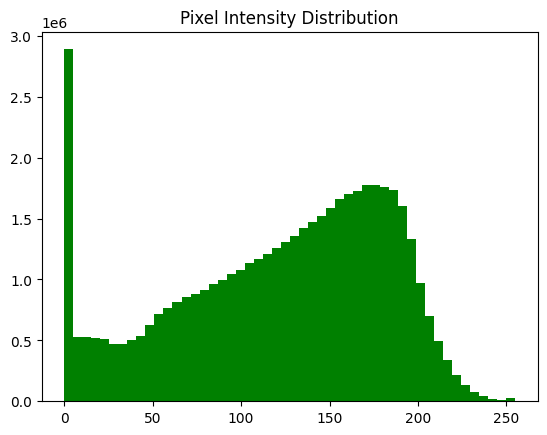

In [ ]:
#Pixel Intensity Distribution
plt.hist(images.flatten(), bins=50, color='green')
plt.title("Pixel Intensity Distribution")
plt.show()

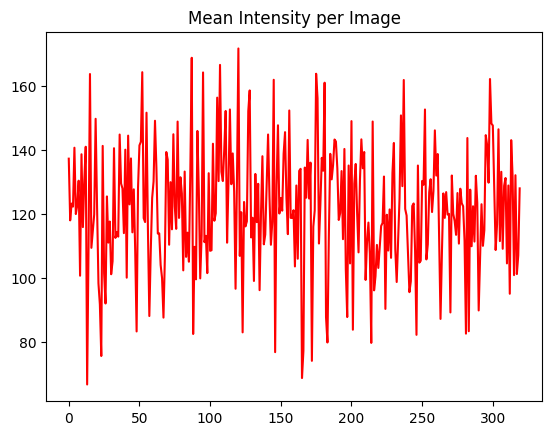

In [ ]:
#Mean Intensity per Image
means = [img.mean() for img in images]
plt.plot(means, color='red')
plt.title("Mean Intensity per Image")
plt.show()

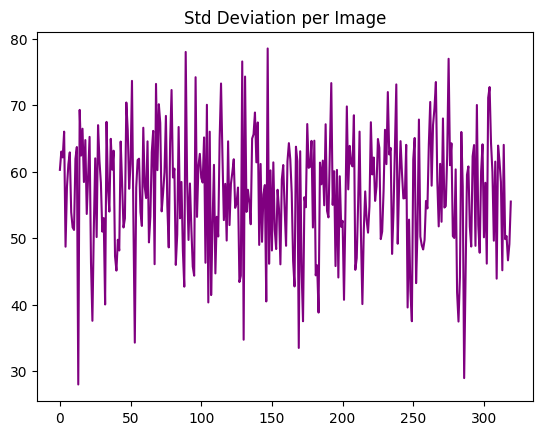

In [ ]:
#Std Deviation per Image
stds = [img.std() for img in images]
plt.plot(stds, color='purple')
plt.title("Std Deviation per Image")
plt.show()

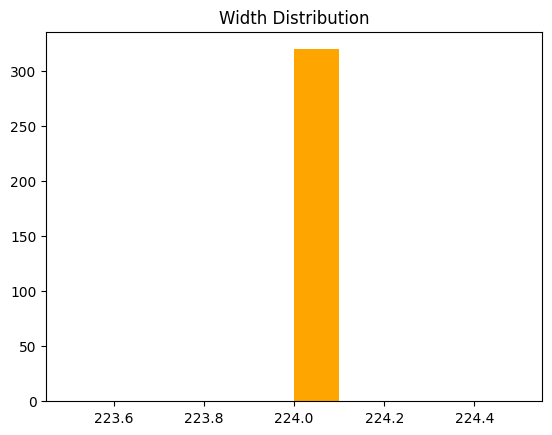

In [ ]:
#Width Distribution
widths = [img.shape[1] for img in images]
plt.hist(widths, color='orange')
plt.title("Width Distribution")
plt.show()

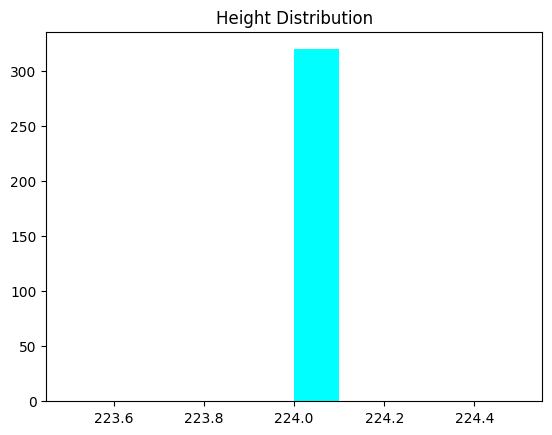

In [ ]:
#Height Distribution
heights = [img.shape[0] for img in images]
plt.hist(heights, color='cyan')
plt.title("Height Distribution")
plt.show()

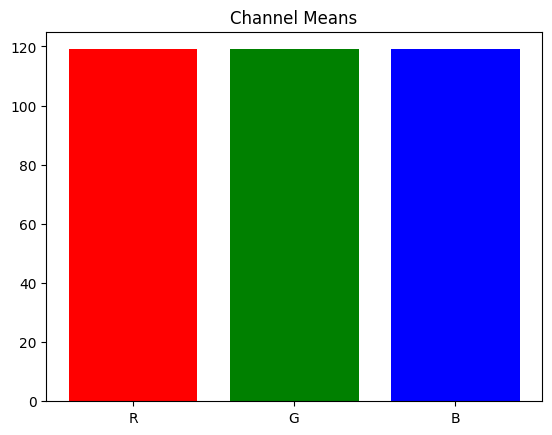

In [ ]:
#Channel mean
channel_means = images.mean(axis=(0,1,2))
plt.bar(['R','G','B'], channel_means, color=['red','green','blue'])
plt.title("Channel Means")
plt.show()

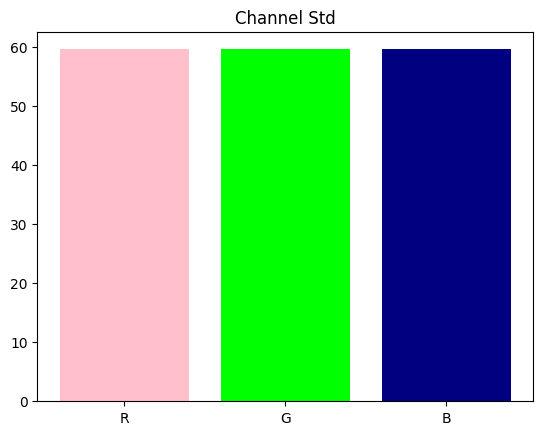

In [ ]:
#Channel standard deviation
channel_std = images.std(axis=(0,1,2))
plt.bar(['R','G','B'], channel_std, color=['pink','lime','navy'])
plt.title("Channel Std")
plt.show()

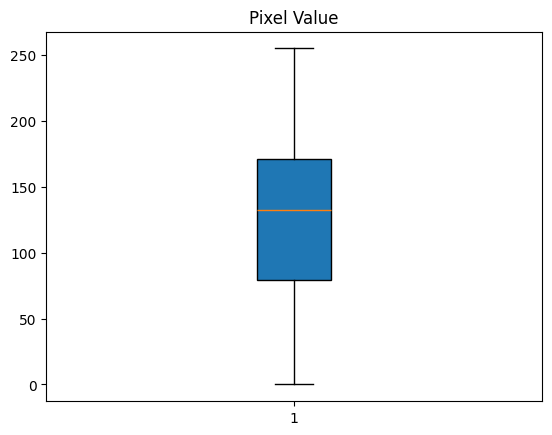

In [ ]:
#Pixel Value
plt.boxplot(images.flatten(), patch_artist=True)
plt.title("Pixel Value")
plt.show()

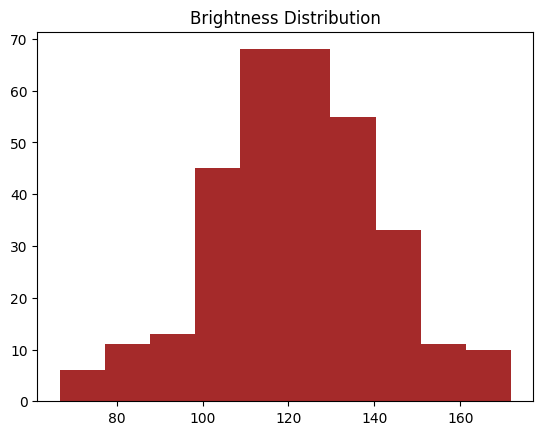

In [ ]:
#Brightness Distribution
brightness = images.mean(axis=(1,2,3))
plt.hist(brightness, color='brown')
plt.title("Brightness Distribution")
plt.show()

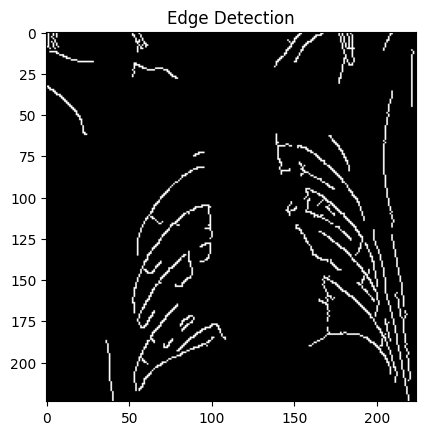

In [ ]:
#Edge detection
edges = cv2.Canny(images[0].astype("uint8"),100,200)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.show()

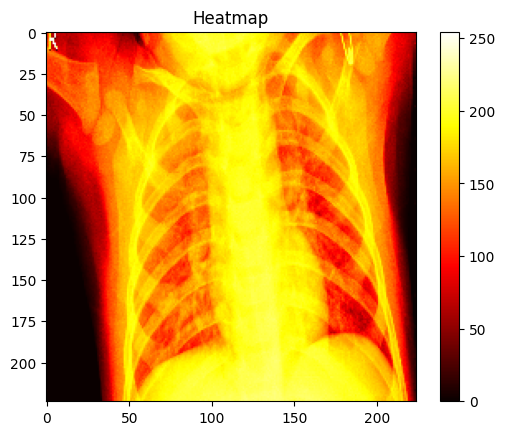

In [ ]:
#Heat Map
plt.imshow(images[0][:,:,0], cmap='hot')
plt.title("Heatmap")
plt.colorbar()
plt.show()

In [ ]:
# CNN Model
def build_cnn():
    model = keras.Sequential([
        layers.Input(shape=(224,224,3)),
        data_augmentation,
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid', dtype='float32')
    ])
    return model

In [ ]:
# EfficientNetB0 LEARNING
def build_transfer_model():
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(224,224,3)
    )
    base_model.trainable = False
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    model = keras.Model(base_model.input, output)
    return model

In [ ]:
# Model Compiling
def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )

In [ ]:
#Training Custom CNN
EPOCHS = 8
cnn_model = build_cnn()
compile_model(cnn_model)
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - accuracy: 0.7359 - auc: 0.4835 - loss: 0.5934 - precision: 0.7429 - recall: 0.9851 - val_accuracy: 0.6250 - val_auc: 0.3760 - val_loss: 0.7081 - val_precision: 0.6250 - val_recall: 1.0000
Epoch 2/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.7422 - auc: 0.5039 - loss: 0.5779 - precision: 0.7422 - recall: 1.0000 - val_accuracy: 0.6250 - val_auc: 0.5599 - val_loss: 0.6638 - val_precision: 0.6250 - val_recall: 1.0000
Epoch 3/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.7425 - auc: 0.6227 - loss: 0.5532 - precision: 0.7439 - recall: 0.9959 - val_accuracy: 0.6250 - val_auc: 0.7176 - val_loss: 0.6134 - val_precision: 0.6368 - val_recall: 0.9308
Epoch 4/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.7569 - auc: 0.7590 - loss: 0.4963 - precision: 0.7719 - recall: 0.9544 - val_accuracy: 0.6298 - val_auc: 0.7238 - val_loss: 0.6280 - val_precision: 0.6378 - val_recall: 0.9436
Epoch 5/8
164/164 ━━━━━━━━━━━━

In [ ]:
# Training EfficientNetB0
tl_model = build_transfer_model()
compile_model(tl_model)
history_tl = tl_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 161s 593ms/step - accuracy: 0.8739 - auc: 0.9297 - loss: 0.3009 - precision: 0.9229 - recall: 0.9057 - val_accuracy: 0.7276 - val_auc: 0.9182 - val_loss: 0.4863 - val_precision: 0.6986 - val_recall: 0.9923
Epoch 2/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9268 - auc: 0.9732 - loss: 0.1842 - precision: 0.9510 - recall: 0.9503 - val_accuracy: 0.7981 - val_auc: 0.9469 - val_loss: 0.4391 - val_precision: 0.7609 - val_recall: 0.9872
Epoch 3/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9419 - auc: 0.9835 - loss: 0.1425 - precision: 0.9623 - recall: 0.9593 - val_accuracy: 0.8093 - val_auc: 0.9538 - val_loss: 0.4749 - val_precision: 0.7715 - val_recall: 0.9872
Epoch 4/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9482 - auc: 0.9869 - loss: 0.1267 - precision: 0.9691 - recall: 0.9609 - val_accuracy: 0.8061 - val_auc: 0.9557 - val_loss: 0.5400 - val_precision: 0.7653 - val_recall: 0.9949
Epoch 5/8
164/164 ━━━━━━━━━━━

In [ ]:
#Evaluation
def evaluate_model(model, dataset):
    y_true = []
    y_pred = []
    for x, y in dataset:
        preds = model.predict(x, verbose=0)
        y_true.extend(y.numpy())
        y_pred.extend(preds)

    y_pred_bin = [1 if p > 0.5 else 0 for p in y_pred]
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_bin))
    print("ROC-AUC:", roc_auc_score(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred_bin)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

CNN Results

Classification Report:
              precision    recall  f1-score   support

         0.0       0.51      0.97      0.66       234
         1.0       0.96      0.44      0.60       390

    accuracy                           0.63       624
   macro avg       0.73      0.70      0.63       624
weighted avg       0.79      0.63      0.62       624

ROC-AUC: 0.8665570896340127


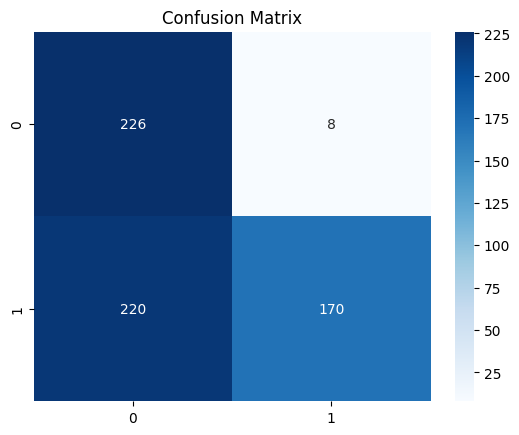

In [ ]:
print("CNN Results")
evaluate_model(cnn_model, test_ds)

EfficientNetB0 Results

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.55      0.70       234
         1.0       0.79      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.88      0.77      0.79       624
weighted avg       0.86      0.83      0.81       624

ROC-AUC: 0.9658338812184966


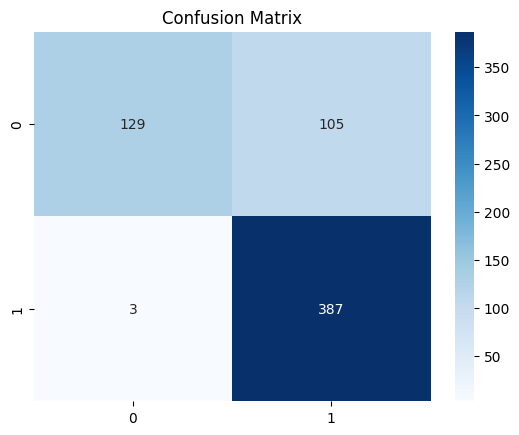

In [ ]:
print("EfficientNetB0 Results")
evaluate_model(tl_model, test_ds)

In [ ]:
#TRAINING METRICS PLOTS
def plot_training(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'], color='blue', label='train_acc')
    plt.plot(history.history['val_accuracy'], color='red', label='val_acc')
    plt.title(title + " Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'], color='green', label='train_loss')
    plt.plot(history.history['val_loss'], color='orange', label='val_loss')
    plt.title(title + " Loss")
    plt.legend()
    plt.show()

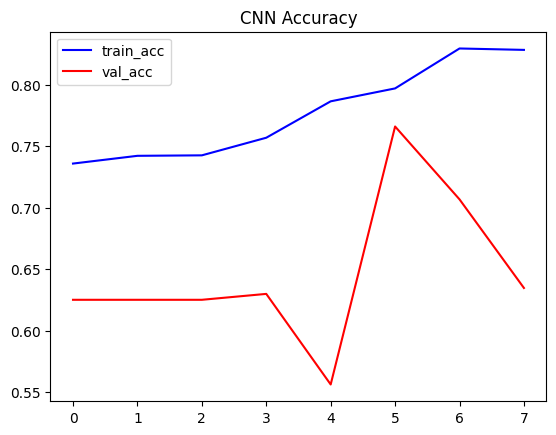

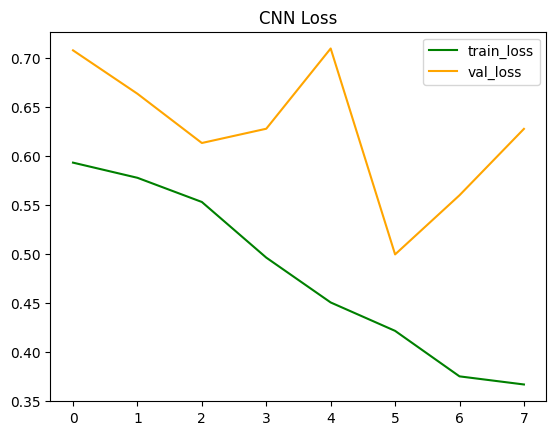

In [ ]:
#CNN
plot_training(history_cnn, "CNN")

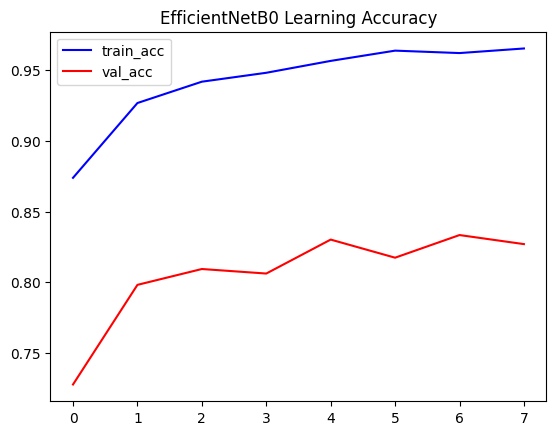

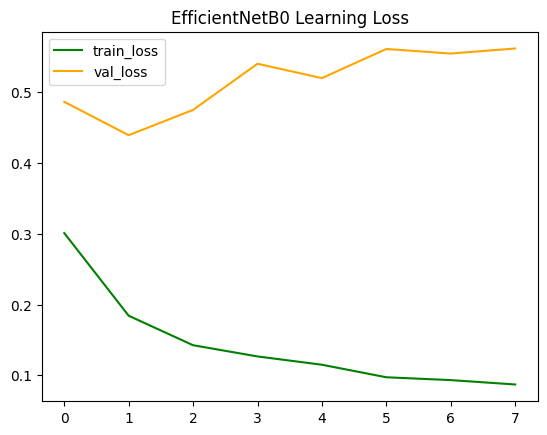

In [ ]:
#EfficientNetB0 Learning
plot_training(history_tl, "EfficientNetB0 Learning")

In [ ]:
#ROC CURVE
def plot_roc(model, dataset, title):
    y_true, y_pred = [], []

    for x, y in dataset:
        preds = model.predict(x, verbose=0)
        y_true.extend(y.numpy())
        y_pred.extend(preds)

    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color='darkorange', label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1], color='navy', linestyle='--')
    plt.title(title + " ROC Curve")
    plt.legend()
    plt.show()

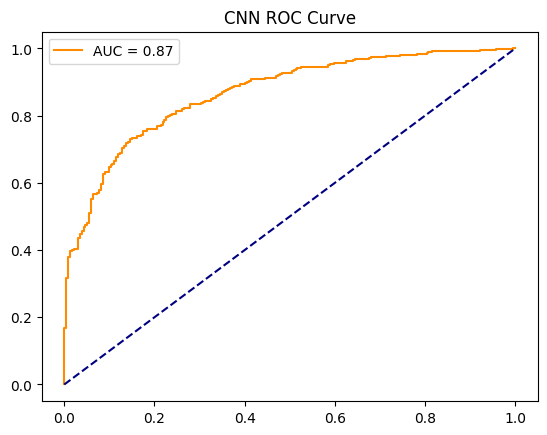

In [ ]:
#CNN
plot_roc(cnn_model, test_ds, "CNN")

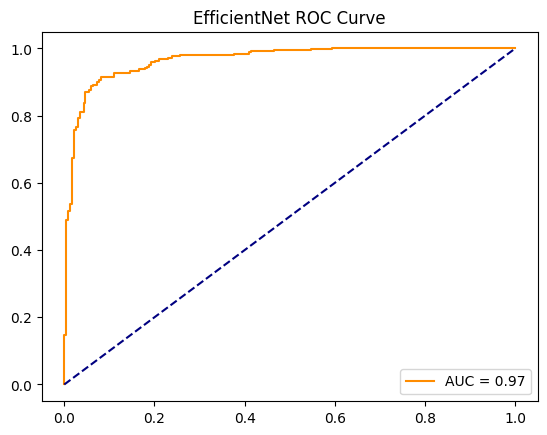

In [ ]:
#Efficietnet
plot_roc(tl_model, test_ds, "EfficientNet")

In [ ]:
# ResNet50 Model
def build_resnet_model():
    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(224,224,3)
    )
    base_model.trainable = False
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    model = keras.Model(base_model.input, output)
    return model

In [ ]:
# DenseNet121 Model
def build_densenet_model():
    base_model = tf.keras.applications.DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(224,224,3)
    )

    base_model.trainable = False
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    model = keras.Model(base_model.input, output)
    return model

In [ ]:
# ResNet50 Training
resnet_model = build_resnet_model()
compile_model(resnet_model)

history_resnet = resnet_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 45s 162ms/step - accuracy: 0.8750 - auc: 0.9584 - loss: 0.2955 - precision: 0.9687 - recall: 0.8594 - val_accuracy: 0.8814 - val_auc: 0.9535 - val_loss: 0.2884 - val_precision: 0.8657 - val_recall: 0.9590
Epoch 2/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9541 - auc: 0.9887 - loss: 0.1239 - precision: 0.9742 - recall: 0.9637 - val_accuracy: 0.8429 - val_auc: 0.9547 - val_loss: 0.4006 - val_precision: 0.8029 - val_recall: 0.9923
Epoch 3/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9669 - auc: 0.9937 - loss: 0.0896 - precision: 0.9801 - recall: 0.9753 - val_accuracy: 0.8429 - val_auc: 0.9577 - val_loss: 0.4469 - val_precision: 0.8042 - val_recall: 0.9897
Epoch 4/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9725 - auc: 0.9959 - loss: 0.0740 - precision: 0.9847 - recall: 0.9781 - val_accuracy: 0.8189 - val_auc: 0.9496 - val_loss: 0.5416 - val_precision: 0.7787 - val_recall: 0.9923
Epoch 5/8
164/164 ━━━━━━━━━━━━

In [ ]:
# DenseNet121 Training
densenet_model = build_densenet_model()
compile_model(densenet_model)

history_densenet = densenet_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 87s 311ms/step - accuracy: 0.7947 - auc: 0.8736 - loss: 0.4355 - precision: 0.9194 - recall: 0.7929 - val_accuracy: 0.8317 - val_auc: 0.8331 - val_loss: 0.5017 - val_precision: 0.8160 - val_recall: 0.9436
Epoch 2/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9209 - auc: 0.9664 - loss: 0.2089 - precision: 0.9554 - recall: 0.9372 - val_accuracy: 0.7965 - val_auc: 0.8807 - val_loss: 0.5189 - val_precision: 0.7594 - val_recall: 0.9872
Epoch 3/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.9448 - auc: 0.9800 - loss: 0.1570 - precision: 0.9658 - recall: 0.9596 - val_accuracy: 0.7740 - val_auc: 0.9039 - val_loss: 0.5616 - val_precision: 0.7371 - val_recall: 0.9923
Epoch 4/8
164/164 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9520 - auc: 0.9856 - loss: 0.1342 - precision: 0.9680 - recall: 0.9673 - val_accuracy: 0.7821 - val_auc: 0.9104 - val_loss: 0.5802 - val_precision: 0.7442 - val_recall: 0.9923
Epoch 5/8
164/164 ━━━━━━━━━━━━

ResNet50 Results

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.53      0.69       234
         1.0       0.78      1.00      0.88       390

    accuracy                           0.82       624
   macro avg       0.89      0.77      0.79       624
weighted avg       0.86      0.82      0.81       624

ROC-AUC: 0.9658338812184966


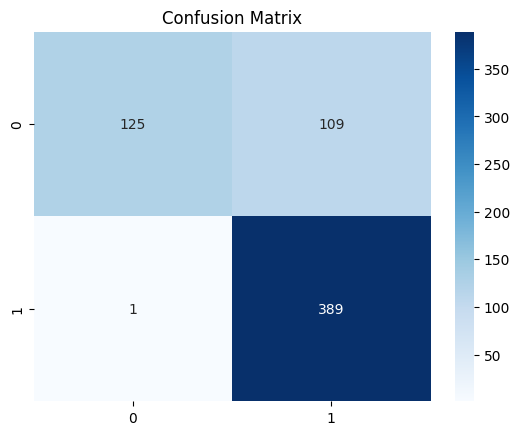

In [ ]:
# Evaluation
print("ResNet50 Results")
evaluate_model(resnet_model, test_ds)

DenseNet121 Results

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.41      0.57       234
         1.0       0.74      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.85      0.70      0.71       624
weighted avg       0.82      0.77      0.74       624

ROC-AUC: 0.920107385492001


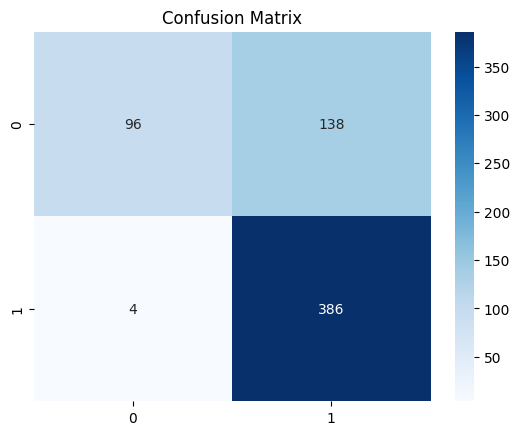

In [ ]:
# Evaluation
print("DenseNet121 Results")
evaluate_model(densenet_model, test_ds)

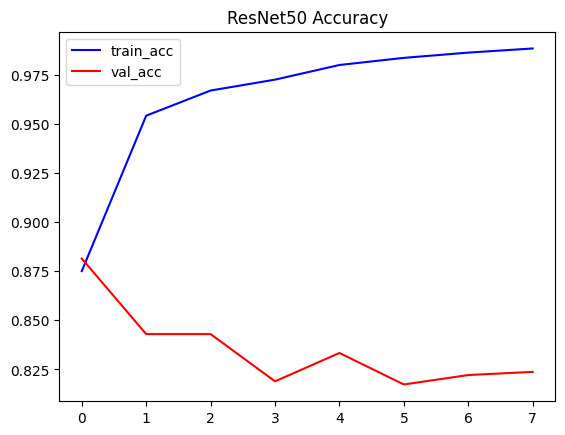

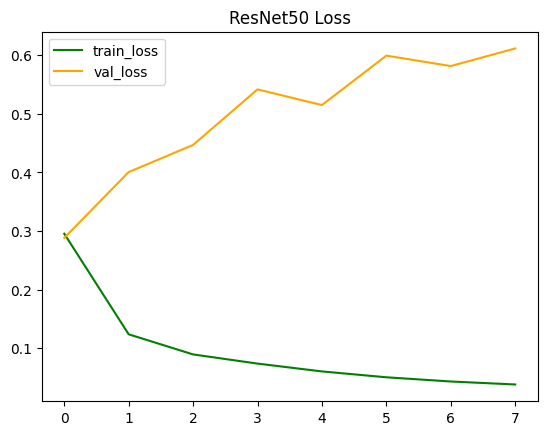

In [ ]:
#TRAINING PLOT
plot_training(history_resnet, "ResNet50")

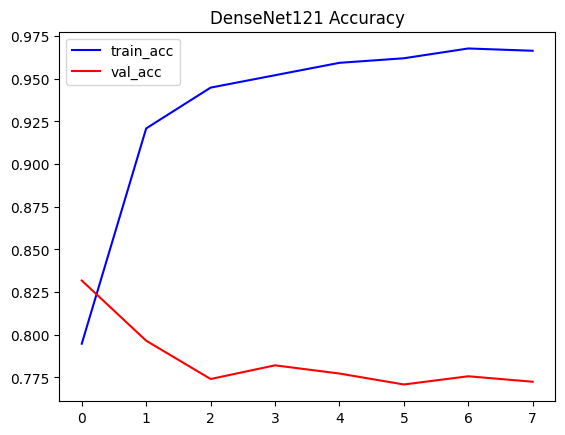

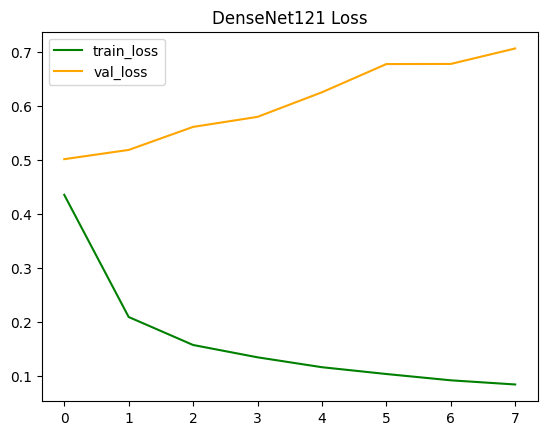

In [ ]:
#TRAINING PLOT
plot_training(history_densenet, "DenseNet121")

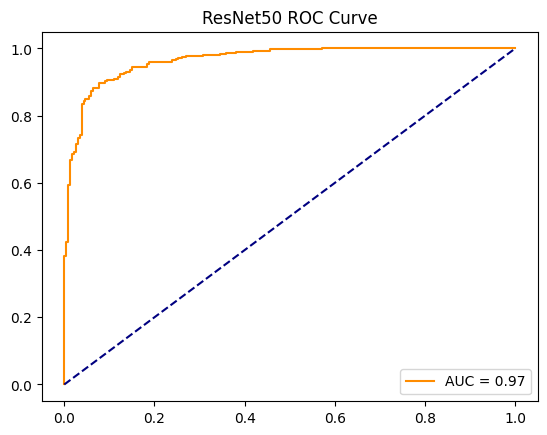

In [ ]:
#ROC
plot_roc(resnet_model, test_ds, "ResNet50")

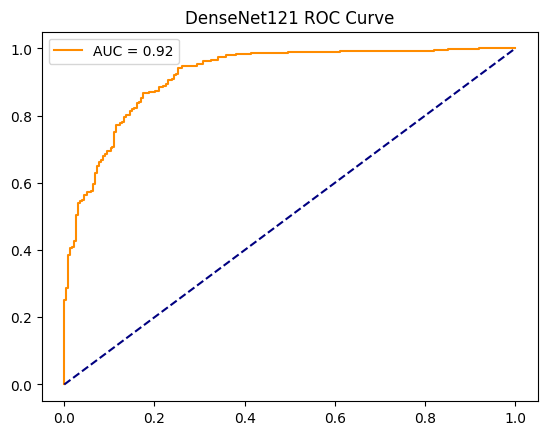

In [ ]:
#ROC
plot_roc(densenet_model, test_ds, "DenseNet121")

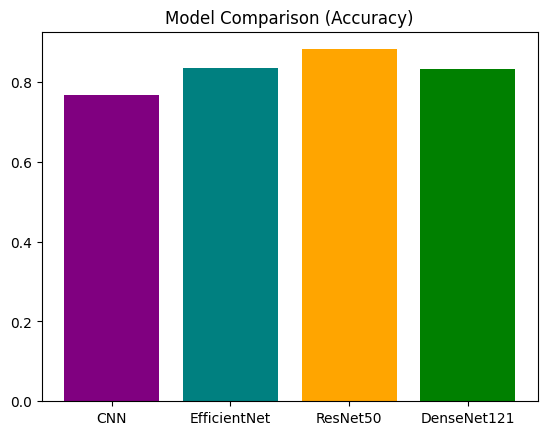

In [ ]:
# Comparision of All models in bar chart
cnn_acc = max(history_cnn.history['val_accuracy'])
tl_acc = max(history_tl.history['val_accuracy'])
resnet_acc = max(history_resnet.history['val_accuracy'])
densenet_acc = max(history_densenet.history['val_accuracy'])

models = ['CNN', 'EfficientNet', 'ResNet50', 'DenseNet121']
scores = [cnn_acc, tl_acc, resnet_acc, densenet_acc]

plt.bar(models, scores, color=['purple','teal','orange','green'])
plt.title("Model Comparison (Accuracy)")
plt.show()

In [ ]:
# Comparision of all models
data = {
    "Model": ["CNN", "EfficientNet", "ResNet50", "DenseNet121"],
    "Validation Accuracy": [cnn_acc, tl_acc, resnet_acc, densenet_acc]
}
results_df = pd.DataFrame(data)
print(results_df)

          Model  Validation Accuracy
0           CNN             0.766026
1  EfficientNet             0.833333
2      ResNet50             0.881410
3   DenseNet121             0.831731
